In [47]:
import numpy as np
import math
import pandas as pd 
import scipy.stats as stats 
import matplotlib.pyplot as plt
from numba.typed import List
import itertools
from scipy.stats import linregress
from numba import njit
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from itertools import product

In [48]:

def give_all_comb(len):
    return [seq  for i, seq in enumerate(product([-1, 1], repeat=len))]


In [49]:
@njit
def seq_to_index(context):
    idx = 0
    for i in range(len(context)):
        idx = idx * 2 + (context[i] == 1)
    return idx

@njit
def homm_get_next_w(context_arr, memorySeq,memoryStrengthPlus, memoryStrengthMinus, order,gamma):
    act_pos = 0.0
    act_neg = 0.0
    
    lag_weights = np.exp(-gamma * (order - 1 - np.arange(order)))
    for i in range(len(memorySeq)):
        memory   = memorySeq[i]
        abs_dif  =  lag_weights*np.abs(memory - context_arr)
        sim      = np.exp(-np.sum(abs_dif))
        strengthPlus = memoryStrengthPlus[i]
        strengthMinus = memoryStrengthMinus[i]

        act_pos += strengthPlus * sim
        act_neg += strengthMinus * sim  # negative -1 evidence → positive +1 evidence

    total = act_pos + act_neg
    if total > 0.0:
        return act_pos / total
    return 0.5

@njit
def homm_add_to_memory(context_arr,resp, confidence, memoryStrengthPlus, memoryStrengthMinus, decay):
    idx = seq_to_index(context_arr)
    memoryStrengthPlus *= decay
    memoryStrengthMinus *= decay

    if resp ==1:
        memoryStrengthPlus[idx] += confidence
    else:
        memoryStrengthMinus[idx] += confidence

@njit
def build_context(resp_arr, i, k):
    context = np.zeros(k, dtype=np.int64)
    start = max(i - k, 0)
    length = i - start
    for j in range(length):
        context[k - length + j] = resp_arr[start + j]
    return context

def normalize_weights(weights, k_w):

    weights = np.asarray(weights, dtype=float)
    target_sum = 2 ** (k_w - 1)
    weights = target_sum * weights / np.sum(weights)

    for _ in range(100):
        excess = np.maximum(0, weights - 1)
        if np.sum(excess) < 1e-12:
            break                                   # all weights in [0, 1]
        weights = np.minimum(weights, 1)            # clip
        good = weights < 1
        if not np.any(good):
            break                                   # no room to redistribute
        weights[good] += np.sum(excess) / np.sum(good)

    return weights

In [50]:
import numpy as np
from numba import njit
from scipy.stats import norm as _norm

# Pre-computed 5-point Gauss-Legendre nodes and weights on [-1, 1]
_GL5_NODES   = np.array([-0.9061798459386640, -0.5384693101056831,
                           0.0,
                           0.5384693101056831,  0.9061798459386640])
_GL5_WEIGHTS = np.array([ 0.2369268850561891,  0.4786286704993665,
                           0.5688888888888889,
                           0.4786286704993665,  0.2369268850561891])

@njit
def _norm_pdf(x):
    return np.exp(-0.5 * x * x) / np.sqrt(2.0 * np.pi)

@njit
def _ddm_pdf_lower_core(t, v, a, w, sv, max_J=50, eps=1e-12):
    """
    Core lower-boundary PDF for a single (v, a, w) triple.
    σ is assumed = 1 here; caller must pre-scale v, a, sv by 1/σ.
    sv = inter-trial drift SD  (set 0 for no drift variability).
    w  = relative starting point in (0,1).
    """
    if t <= 0.0:
        return 1e-300
    if t < 1e-6:
        t = 1e-6

    one_plus = 1.0 + sv * sv * t
    denom = np.sqrt(t**3 * one_plus)

    expo = np.exp(
        (-(v * v) * t - 2.0 * v * a * w + (sv * sv) * (a * w) * (a * w))
        / (2.0 * one_plus)
    )

    sqrt_t = np.sqrt(t)
    s = 0.0
    prev_term = 0.0

    for j in range(max_J):
        if j % 2 == 0:
            rj = j * a + a * w
        else:
            rj = j * a + a * (1.0 - w)

        term = ((-1) ** j) * rj * _norm_pdf(rj / sqrt_t)
        s += term

        if j > 3 and np.abs(term) < eps and np.abs(prev_term) < eps:
            break
        prev_term = term

    pdf = (expo / denom) * s
    return max(pdf, 1e-300)


@njit
def ddm_pdf_lower_boundary(t, v, a, w, t0,
                            sv=0.0, sz=0.0, sigma=1.0,
                            max_J=50, eps=1e-12):
    """
    Lower-boundary PDF with:
      σ   (sigma)  – diffusion coefficient  [scales v, a, sv]
      sv           – inter-trial drift SD
      sz           – uniform starting-point range  w ~ Uniform(w-sz/2, w+sz/2)
                     integrated via 5-point Gauss-Legendre quadrature

    Reference for σ scaling:
        Blurton et al. (2017), J. Math. Psych. 76, 7-12  (eq. 1 footnote)
    Reference for sz quadrature approach:
        Ratcliff & Tuerlinckx (2002), Psychon. Bull. Rev. 9, 438-481
        (HDDM and fddm both implement sz this way in practice)
    """
    t_eff = t - t0
    if t_eff <= 0.0:
        return 1e-300

    # -------------------------------------------------------
    # σ handling: pure rescaling (σ is a scale parameter)
    # v/σ, a/σ, sv/σ are the normalised parameters
    # -------------------------------------------------------
    if sigma != 1.0:
        v  = v  / sigma
        a  = a  / sigma
        sv = sv / sigma

    # -------------------------------------------------------
    # sz = 0 → no starting-point variability, fast path
    # -------------------------------------------------------
    if sz <= 1e-10:
        return _ddm_pdf_lower_core(t_eff, v, a, w, sv, max_J, eps)

    # -------------------------------------------------------
    # sz > 0: Gauss-Legendre quadrature over
    #   w' ∈ [w - sz/2, w + sz/2]  (clipped to (0,1))
    #
    # (1/sz) ∫_{w-sz/2}^{w+sz/2} f(t|w') dw'
    #  = (1/2) Σ_i weight_i * f(t | w + (sz/2)*node_i)
    # -------------------------------------------------------
    # Hard-coded 5-point GL nodes and weights (on [-1, 1])
    n0 = -0.9061798459386640;  wt0 = 0.2369268850561891
    n1 = -0.5384693101056831;  wt1 = 0.4786286704993665
    n2 =  0.0;                 wt2 = 0.5688888888888889
    n3 =  0.5384693101056831;  wt3 = 0.4786286704993665
    n4 =  0.9061798459386640;  wt4 = 0.2369268850561891

    half_sz = sz * 0.5
    acc = 0.0

    for (node, wt) in ((n0, wt0), (n1, wt1), (n2, wt2), (n3, wt3), (n4, wt4)):
        w_prime = w + half_sz * node

        # Clip to valid range – avoid boundary singularities
        if w_prime <= 0.0:
            w_prime = 1e-6
        elif w_prime >= 1.0:
            w_prime = 1.0 - 1e-6

        acc += wt * _ddm_pdf_lower_core(t_eff, v, a, w_prime, sv, max_J, eps)

    pdf = 0.5 * acc          # factor 1/2 from change-of-variables
    return max(pdf, 1e-300)


def complete_run(data, params,weights):
    vSlope,vPower,vBias,a,t0,w,k,weight_w,weight_v,lapse,strength_bias,decay = params
    winf = 0.2
    k_w = k

    w_part_1 = np.asarray(weights)
    w_part_2 = np.ones_like(weights) - np.flip(weights)
    weigths_use = np.concatenate((w_part_1,w_part_2))

    


    memorySeq      = np.asarray(give_all_comb(k))

    memoryStrengthPlus = np.asarray([p*strength_bias for p in weigths_use])
    memoryStrengthMinus = np.asarray([(1-p)*strength_bias for p in weigths_use])
    

    

    return complete_run_fast(
        data["coherence"].to_numpy(np.float64),
        data["stim"].to_numpy(np.int8),
        data["response"].to_numpy(np.int8),
        data["rt"].to_numpy(np.float64),
        memorySeq, memoryStrengthPlus,memoryStrengthMinus,
        vSlope,vPower,vBias,a, t0, w, k,
        weight_w, weight_v, lapse,decay,winf
    )
@njit
def _sigmoid(x):
    if x >= 0:
        return 1.0 / (1.0 + np.exp(-x))
    ex = np.exp(x)
    return ex / (1.0 + ex)


@njit
def conf_2dsd(v_signed, a, resp, tau, sigma=1.0):

    mean_tc = a + resp * v_signed * tau
    sd = sigma * math.sqrt(tau)
    z = mean_tc / sd
    return 0.5 * (1.0 + math.erf(z * 0.7071067811865476))

@njit
def complete_run_fast(coherence, stim, resp, rt,
                      memorySeq, memoryStrengthPlus,memoryStrengthMinus,
                      vSlope,vPower,vBias,a, t0, w, k,
                      weight_w, weight_v, lapse,d,winf):
    n = len(stim)
    likelihood = 0.0

    DecayShortP = np.zeros_like(memoryStrengthPlus)
    DecayShortM = np.zeros_like(memoryStrengthMinus)
    for i in range(n):
        
        a_orig = a
        
        context = build_context(resp, i, k)
        
        gamma= 0.0
        p_pos = homm_get_next_w(context, memorySeq,(1-winf)*DecayShortP + (winf)*memoryStrengthPlus, (1-winf)*DecayShortM + (winf)*memoryStrengthMinus, k,gamma)

        

        a_eff = a_orig
        
        #print(f"this is the first {context}")

        pred_correct_dir = p_pos if stim[i] == 1 else (1.0 - p_pos)
        w_logit = np.log(w / (1.0 - w))
        w_up = _sigmoid(w_logit + weight_w * (2*p_pos - 1))


        w_sz = 0.0 #np.sqrt((weight_v**2 * 4*p_pos*(1-p_pos)) * tau)

        

        v_base = vSlope*coherence[i]**vPower + weight_v*(2*pred_correct_dir - 1)
        
        v_signed = v_base if stim[i] == 1 else -v_base

        # Step 3: add directional bias AFTER sign
        # vBias > 0 always pushes toward stim==1 boundary
        v_biased = v_signed + vBias

        # Step 4: fold for response (DDM lower-boundary trick)
        if resp[i] == 1:   # chose right
            v_eff = v_biased
            w_eff = w_up 
        else:              # chose left
            v_eff = -v_biased
            w_eff = 1.0 - w_up
        


        p_ddm   =  ddm_pdf_lower_boundary(rt[i], -v_eff, a_eff, 1.0-w_eff, t0,sz = w_sz)
        p_lapse = 0.5 / (4.0 - 0.15)
        p = (1.0 - lapse)*p_ddm + lapse*p_lapse
        if p > 0:
            likelihood += math.log(p)

        if i >= k and resp[i] != 0:

            p_resp = max(p_pos if resp[i] == 1 else (1.0 - p_pos), 1e-10)
            weight    = -np.log(p_resp)
            direction = resp[i]


            homm_add_to_memory(context, direction, weight,
                            memoryStrengthPlus, memoryStrengthMinus, 1.0)
            homm_add_to_memory(context, direction, weight,
                            DecayShortP, DecayShortM, d)


    return likelihood

In [51]:
import numpy as np
import cma

# ── Indices into the 13 non-weight params ──────────────────────────────────
DDM_IDX     = [0, 1, 2, 3, 4, 5, 8, 11]   # vSlope, vPower, vBias, a, t0, w, lapse, d
MEMORY_IDX  = [6, 7, 9, 10]            # weight_w, weight_v, gamma, bias_strength, ptau

# Neutral unit-cube values for frozen memory params during stage 1
MEMORY_NEUTRAL = [0.0, 0.0, 0.0, 0.0]

def make_rescale(bl, bh, ls):
    safe_bl = np.where(ls, bl, 1.0)
    safe_bh = np.where(ls, bh, 1.0)
    def rescale(x_unit):
        x = np.asarray(x_unit)
        log_vals = safe_bl * (safe_bh / safe_bl) ** x
        lin_vals = bl + x * (bh - bl)
        return np.where(ls, log_vals, lin_vals)
    return rescale


def fit_ddm_stage(df_participant, rescale, bounds_low, bounds_high, n_w,
                  n_restarts=5, maxiter=400):
    """Stage 1: fit only DDM params with memory frozen to neutral values."""
    n_params     = len(bounds_low)
    n_non_weight = n_params - n_w

    def neg_log_lik_ddm(x_ddm_unit):
        x_full = np.zeros(n_params)
        x_full[DDM_IDX]           = x_ddm_unit[:len(DDM_IDX)]
        x_full[MEMORY_IDX]        = MEMORY_NEUTRAL
        x_full[n_non_weight:]     = 0.5
        params = rescale(np.clip(x_full, 0.0, 1.0))
        vSlope, vPower, vBias, a, t0, w, weight_w, weight_v, lapse, bias_strength, d = params[:11]
        weights = params[11:]
        full_params = (vSlope, vPower, vBias, a, t0, w, 1,
                       weight_w, weight_v, lapse, bias_strength, d)
        ll = -complete_run(df_participant, full_params, weights)
        return ll if np.isfinite(ll) else 1e10

    n_ddm      = len(DDM_IDX)
    best_val   = np.inf
    best_x_ddm = None

    for _ in range(n_restarts):
        x0     = np.random.uniform(0.0, 1.0, n_ddm)
        sigma0 = 0.3

        opts = cma.CMAOptions()
        opts['bounds']        = [[0.0]*n_ddm, [1.0]*n_ddm]
        opts['maxiter']       = maxiter
        opts['popsize']       = 15
        opts['tolstagnation'] = 30
        opts['tolfun']        = 1e-5
        opts['tolx']          = 1e-5
        opts['verbose']       = -9
        opts['seed']          = np.random.randint(0, 100000)

        try:
            es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
            es.optimize(neg_log_lik_ddm)
            result = es.result
            if np.isfinite(result.fbest) and result.fbest < best_val:
                best_val   = result.fbest
                best_x_ddm = np.clip(result.xbest, 0.0, 1.0)
        except Exception:
            continue

    print(f"  Stage 1 DDM fit: LL = {-best_val:.2f}")
    return best_x_ddm


def fit_mle(df_participant, n_restarts=8, k_values=range(1, 5), fast=False):

    best_overall = {"params": None, "k": None, "neg_ll": np.inf, "aic": np.inf, "param_names": None}
    print(f"Running optimization for k = {list(k_values)}")

    # ── Stage 1: run ONCE, outside k-loop ─────────────────────────────────
    n_w_s1       = 1
    bounds_low_s1  = np.array([0.01, 0.01, -4.0, 0.1, 0.0, 0.3, 0.000001, 0.0000001, 0.0, 0.00001, 0.9] + [0.0]*n_w_s1)
    bounds_high_s1 = np.array([10.0, 2.0,   4.0,  5.0, 0.5, 0.7, 100.0,   30.0,   0.05, 2000.0, 1.0 ] + [1.0]*n_w_s1)
    log_scale_s1   = np.array([False, False, False, False, False, False, False, False, False, True, False] + [False]*n_w_s1)
    rescale_s1     = make_rescale(bounds_low_s1, bounds_high_s1, log_scale_s1)

    print("Running Stage 1 (DDM only)...")
    ddm_x_unit = fit_ddm_stage(df_participant, rescale_s1, bounds_low_s1, bounds_high_s1, n_w_s1)

    # ── Stage 2: k-loop with full fits ────────────────────────────────────
    for k in k_values:
        k_w = min(5, k) - 1
        n_w = 2**k_w

        bounds_low  = np.array([0.01, 0.01, -4.0, 0.1, 0.0, 0.3, 0.000001, 0.0000001, 0.0, 0.00001, 0.9] + [0.0]*n_w)
        bounds_high = np.array([10.0, 1.0,   4.0,  5.0, 0.5, 0.7, 30.0,   30.0,   0.05, 2000.0, 1.0  ] + [1.0]*n_w)
        log_scale   = np.array([False, False, False, False, False, False, False, False, False, True, False] + [False]*n_w)

        param_names = ["vSlope","vPower","vBias","a","t0","w","weight_w","weight_v",
                       "lapse","bias_strength","d"] + ["w" + str(i) for i in range(n_w)]
        n_params = len(bounds_low)

        print(f"\n=== Optimizing with fixed k = {k} (n_params={n_params}) ===")

        rescale = make_rescale(bounds_low, bounds_high, log_scale)

        def neg_log_lik(params_unit):
            params = rescale(np.clip(params_unit, 0.0, 1.0))
            vSlope, vPower, vBias, a, t0, w, weight_w, weight_v, lapse, bias_strength, d = params[:11]
            weights = params[11:]
            full_params = (vSlope, vPower, vBias, a, t0, w, k, weight_w, weight_v, lapse, bias_strength, d)
            ll = -complete_run(df_participant, full_params, weights)
            return ll if np.isfinite(ll) else 1e10

        best_k_params   = None
        best_k_val      = np.inf
        successful_fits = 0

        print("  Running Stage 2 (full fit)...")
        for i in range(n_restarts):
            x0 = np.random.uniform(0.0, 1.0, n_params)
            if i % 4 != 0 and ddm_x_unit is not None:
                x0[DDM_IDX]    = np.clip(ddm_x_unit + np.random.normal(0, 0.05, len(DDM_IDX)), 0.0, 1.0)
                x0[MEMORY_IDX] = np.random.uniform(0.0, 1.0, len(MEMORY_IDX))

            sigma0 = 0.3
            opts = cma.CMAOptions()
            opts['bounds']        = [[0.0]*n_params, [1.0]*n_params]
            opts['maxiter']       = 200 if fast else 700 + 100*k_w
            opts['popsize']       = 10  if fast else 10
            opts['tolstagnation'] = 15  if fast else 50 + 10*k_w
            opts['tolfun']        = 1e-3
            opts['tolx']          = 1e-3
            opts['verbose']       = -9
            opts['seed']          = np.random.randint(0, 100000)
            opts['CMA_stds']      = [1.0] * n_params

            try:
                es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
                es.optimize(neg_log_lik)
                result = es.result
                if np.isfinite(result.fbest):
                    successful_fits += 1
                    if result.fbest < best_k_val:
                        best_k_val    = result.fbest
                        best_k_params = rescale(np.clip(result.xbest, 0.0, 1.0))
                        print(f"  Restart {i+1} ({'warm' if i%4!=0 else 'random'}): "
                              f"LL = {-best_k_val:.2f}  [{result.stop}]")
            except Exception as e:
                print(f"  Restart {i+1} failed: {e}")
                continue

        print(f"  Successful fits for k={k}: {successful_fits}/{n_restarts}")

        if best_k_params is not None:
            k_aic = 2 * n_params + 2 * best_k_val
            print(f"  AIC for k={k}: {k_aic:.2f}  (vs current best: {best_overall['aic']:.2f})")
            if k_aic < best_overall["aic"]:
                best_overall["neg_ll"]      = best_k_val
                best_overall["aic"]         = k_aic
                best_overall["params"]      = np.asarray(list(best_k_params) + [-1.0] * (2**4 - n_w))
                best_overall["k"]           = k
                best_overall["param_names"] = param_names

    if best_overall["params"] is not None:
        print("\n=== Best overall fit (by AIC) ===")
        print(f"k = {best_overall['k']}")
        for name, val in zip(best_overall["param_names"], best_overall["params"]):
            print(f"  {name}: {val:.4f}")
        print(f"Final Log-Likelihood : {-best_overall['neg_ll']:.2f}")
        print(f"Final AIC            : {best_overall['aic']:.2f}")
        return best_overall["params"], best_overall["k"], -best_overall["neg_ll"], best_overall["aic"]
    else:
        print("No successful fits found!")
        return None, None, None, None

In [52]:



def fit_all_participants(df_path, output_path=None, test_first_n=None):
    """Fit RDM to all participants"""
    
    # Load data
    df = pd.read_csv(df_path)
    df["orig_order"] = np.arange(len(df))

    df = (
        df.sort_values(["sj", "session", "orig_order"])
        .reset_index(drop=True)
    )



    print(f"Loaded data with {len(df)} rows")
    print(f"Unique participants: {df['sj'].nunique()}")
    print(f"Columns: {list(df.columns)}")
    
    # Check data structure
    print("\nData preview:")
    print(df.head())
    
    # Initialize results list
    results = []
    
    # Get participant list
    participants = df['sj'].unique()
    if test_first_n:
        participants = participants[:test_first_n]
        print(f"Testing first {test_first_n} participants only")

    
    # Loop over participants
    for i, participant_id in enumerate(participants):
        print(f"\n{'='*50}")
        print(f"Fitting participant {participant_id} ({i+1}/{len(participants)})")
        print(f"{'='*50}")
        
        participant_df = df[df['sj'] == participant_id]
        print(f"Participant has {len(participant_df)} trials")
        

        params,k, max_ll,aic = fit_mle(participant_df, n_restarts=3)  # Fewer restarts for testing
        
        if params is not None:
            results.append([participant_id] + list(params) + [k] + [max_ll] + [aic])
            print(f"✓ Success: LL = {max_ll:.2f}")
        else:
            results.append([participant_id] + [None] * 11 + [None])
            print("✗ Failed: No valid fit found")
                
    
    # Create results DataFrame
    columns = ["id","vSlope","vPower","vBias","a","t0","w","weight_w","weight_v","lapse","bias_strength","d"]+["w" + str(i) for i in range(2**4)]+["k", "max_log_lik","aic"]

    results_df = pd.DataFrame(results, columns=columns)

    print(f"\nParameter summary (successful fits only):")
    numeric_cols = columns

    print(results_df[numeric_cols].describe())
    
    # Save results
    if output_path:
        results_df.to_csv(output_path, index=False)
        print(f"\nResults saved to: {output_path}")
    
    return results_df

# Example usage:
if __name__ == "__main__":
    # Test with first few participants only
    results_df = fit_all_participants(
        df_path="../data_all_subjects.csv",
        output_path="SPRBLnoGamma.csv",
        test_first_n=25  # Test with first 3 participants only
    )
    
    print("\nFirst few results:")
    print(results_df)

Loaded data with 78201 rows
Unique participants: 22
Columns: ['Unnamed: 0', 'sj', 'condition', 'session', 'block', 'coherence', 'stim', 'response', 'rt', 'orig_order']

Data preview:
   Unnamed: 0   sj condition  session  block  coherence  stim  response  \
0           0  1.0   Neutral      1.0    1.0        0.6   1.0       1.0   
1           1  1.0   Neutral      1.0    1.0        0.0   1.0      -1.0   
2           2  1.0   Neutral      1.0    1.0        0.0   1.0      -1.0   
3           3  1.0   Neutral      1.0    1.0        0.4  -1.0      -1.0   
4           4  1.0   Neutral      1.0    1.0        0.4  -1.0      -1.0   

      rt  orig_order  
0  0.319           0  
1  0.433           1  
2  0.500           2  
3  0.267           3  
4  0.317           4  
Testing first 25 participants only

Fitting participant 1.0 (1/22)
Participant has 3408 trials
Running optimization for k = [1, 2, 3, 4]
Running Stage 1 (DDM only)...
  Stage 1 DDM fit: LL = 853.74

=== Optimizing with fixed k =

In [58]:
import pandas as pd
df2 = pd.read_csv("SPRBLnoGamma.csv")
round(df2["k"],3)

0     1
1     1
2     4
3     1
4     4
5     4
6     2
7     4
8     2
9     3
10    2
11    3
12    1
13    4
14    1
15    3
16    1
17    2
18    1
19    4
20    2
21    3
Name: k, dtype: int64

In [54]:
df = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/ForFirstDraftVbias/PureDDM.csv")
round(df[list(df.columns[1:4]) + ["w","t0"]],2)

,vSlope,vPower,vBias,w,t0
0,4.32,0.71,1.30,0.43,0.01
1,4.73,0.45,-0.23,0.54,0.22
2,6.58,0.63,-0.78,0.53,0.26
3,4.42,0.38,0.08,0.50,0.15
4,6.40,0.52,-0.42,0.56,0.24
5,2.69,0.50,-0.10,0.52,0.38
6,4.06,0.33,0.65,0.48,0.31
7,3.75,0.27,-0.18,0.54,0.40
8,3.13,0.28,-0.02,0.50,0.33
9,5.28,0.43,-0.15,0.51,0.45


In [55]:
df2_par - round(df[list(df.columns[1:4]) + ["w"]],2)

NameError: name 'df2_par' is not defined


SW  (N=22)
  Mean Δ: -0.0307  (↓)
  BF₁₀ (one-sided): 3.908
  BF₀₁ (one-sided): 0.256

SV  (N=22)
  Mean Δ: -0.1326  (↓)
  BF₁₀ (one-sided): 2.334
  BF₀₁ (one-sided): 0.428


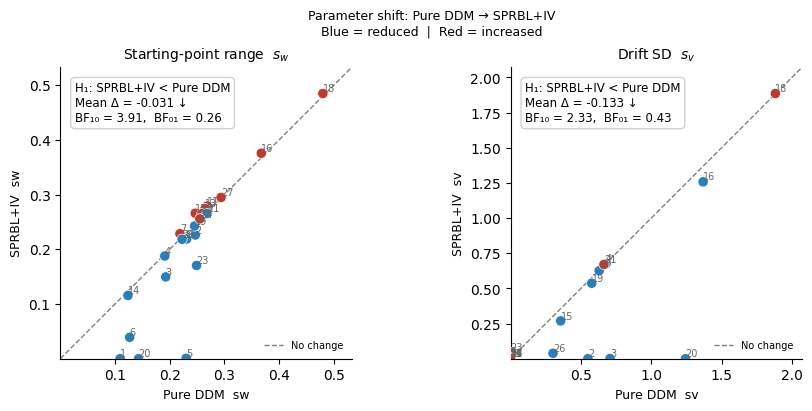

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg

df_ddm    = pd.read_csv("PureDDM.csv")
df_sprbl2 = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/FrundImplementation/SPRBLnoGammaIV.csv")

shared_ids = df_sprbl2["id"].values
ddm_vals   = df_ddm.set_index("id").loc[shared_ids]
spr_vals   = df_sprbl2.set_index("id").loc[shared_ids]

params = [
    {"col": "sw", "label": "Starting-point range  $s_w$"},
    {"col": "sv", "label": "Drift SD  $s_v$"},
]

def parse_BF10(val):
    try:
        return float(val)
    except (ValueError, TypeError):
        return 1e10

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

for ax, param in zip(axes, params):
    col = param["col"]
    x   = ddm_vals[col].values.astype(float)   # Pure DDM
    y   = spr_vals[col].values.astype(float)   # SPRBL+IV
    ids = shared_ids

    mean_diff = np.mean(y - x)

    # ── Bayesian one-sided test (H1: SPRBL < DDM) ─────────────────────────────
    bayes = pg.ttest(y, x, paired=True)
    BF10_two = parse_BF10(bayes["BF10"].values[0])
    BF10_one = 2 * BF10_two if mean_diff < 0 else BF10_two / 2
    BF01_one = 1 / BF10_one

    # ── Plot ──────────────────────────────────────────────────────────────────
    lim_lo = min(x.min(), y.min()) * 0.9
    lim_hi = max(x.max(), y.max()) * 1.1

    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            color="gray", lw=1, ls="--", zorder=1, label="No change")

    colors = ["#c0392b" if yi > xi else "#2980b9" for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, s=55, zorder=3, edgecolors="white", lw=0.5)

    for xi, yi, pid in zip(x, y, ids):
        ax.text(xi, yi, str(int(pid)), fontsize=7,
                ha="left", va="bottom", color="#666", zorder=4)

    # ── Single clean annotation ───────────────────────────────────────────────
    direction = "↓" if mean_diff < 0 else "↑"
    annotation = (
        f"H₁: SPRBL+IV < Pure DDM\n"
        f"Mean Δ = {mean_diff:+.3f} {direction}\n"
        f"BF₁₀ = {BF10_one:.2f},  BF₀₁ = {BF01_one:.2f}"
    )
    ax.text(0.05, 0.95, annotation,
            transform=ax.transAxes, fontsize=8.5,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#ccc", alpha=0.9))

    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect("equal")
    ax.set_xlabel(f"Pure DDM  {col}", fontsize=9)
    ax.set_ylabel(f"SPRBL+IV  {col}", fontsize=9)
    ax.set_title(param["label"], fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, frameon=False, loc="lower right")

    print(f"\n{col.upper()}  (N={len(x)})")
    print(f"  Mean Δ: {mean_diff:+.4f}  ({direction})")
    print(f"  BF₁₀ (one-sided): {BF10_one:.3f}")
    print(f"  BF₀₁ (one-sided): {BF01_one:.3f}")

fig.suptitle(
    "Parameter shift: Pure DDM → SPRBL+IV\n"
    "Blue = reduced  |  Red = increased",
    fontsize=9,
)
plt.savefig("iv_parameter_shift.pdf", bbox_inches="tight")
plt.savefig("iv_parameter_shift.png", dpi=150, bbox_inches="tight")
plt.show()


SW  (N=22)
  Median Δ:    -0.0030  (↓)
  Wilcoxon W:  79.0,  p=0.129  n.s.

SV  (N=22)
  Median Δ:    +0.0000  (↑)
  Wilcoxon W:  101.0,  p=0.424  n.s.


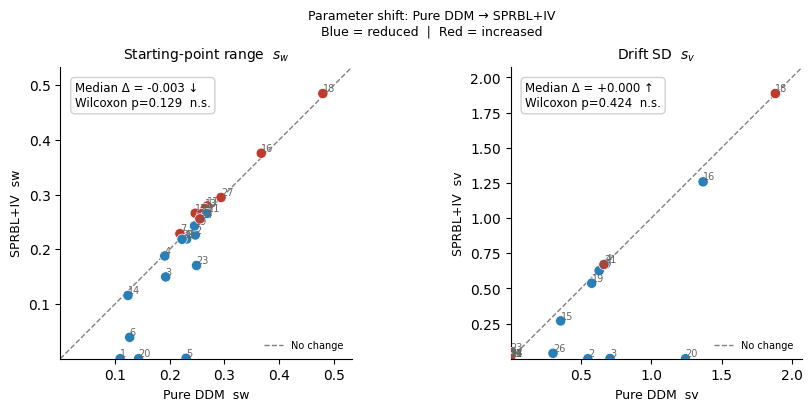

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

df_ddm    = pd.read_csv("PureDDM.csv")
df_sprbl2 = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/FrundImplementation/SPRBLnoGammaIV.csv")

shared_ids = df_sprbl2["id"].values
ddm_vals   = df_ddm.set_index("id").loc[shared_ids]
spr_vals   = df_sprbl2.set_index("id").loc[shared_ids]

params = [
    {"col": "sw", "label": "Starting-point range  $s_w$"},
    {"col": "sv", "label": "Drift SD  $s_v$"},
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

for ax, param in zip(axes, params):
    col = param["col"]
    x   = ddm_vals[col].values.astype(float)   # Pure DDM
    y   = spr_vals[col].values.astype(float)   # SPRBL+IV
    ids = shared_ids

    diff        = y - x
    median_diff = np.median(diff)
    direction   = "↓" if median_diff < 0 else "↑"

    # ── Wilcoxon two-sided ────────────────────────────────────────────────────
    stat, p = wilcoxon(diff, zero_method='wilcox')
    p_str = "p<.001" if p < .001 else f"p={p:.3f}"
    sig_label = (
        "***" if p < 0.001 else
        "**"  if p < 0.01  else
        "*"   if p < 0.05  else
        "n.s."
    )

    # ── Plot ──────────────────────────────────────────────────────────────────
    lim_lo = min(x.min(), y.min()) * 0.9
    lim_hi = max(x.max(), y.max()) * 1.1

    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            color="gray", lw=1, ls="--", zorder=1, label="No change")

    colors = ["#c0392b" if yi > xi else "#2980b9" for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, s=55, zorder=3, edgecolors="white", lw=0.5)

    for xi, yi, pid in zip(x, y, ids):
        ax.text(xi, yi, str(int(pid)), fontsize=7,
                ha="left", va="bottom", color="#666", zorder=4)

    # ── Annotation ────────────────────────────────────────────────────────────
    annotation = (
        f"Median Δ = {median_diff:+.3f} {direction}\n"
        f"Wilcoxon {p_str}  {sig_label}"
    )
    ax.text(0.05, 0.95, annotation,
            transform=ax.transAxes, fontsize=8.5,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#ccc", alpha=0.9))

    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect("equal")
    ax.set_xlabel(f"Pure DDM  {col}", fontsize=9)
    ax.set_ylabel(f"SPRBL+IV  {col}", fontsize=9)
    ax.set_title(param["label"], fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, frameon=False, loc="lower right")

    print(f"\n{col.upper()}  (N={len(x)})")
    print(f"  Median Δ:    {median_diff:+.4f}  ({direction})")
    print(f"  Wilcoxon W:  {stat:.1f},  {p_str}  {sig_label}")

fig.suptitle(
    "Parameter shift: Pure DDM → SPRBL+IV\n"
    "Blue = reduced  |  Red = increased",
    fontsize=9,
)
plt.savefig("iv_parameter_shift.pdf", bbox_inches="tight")
plt.savefig("iv_parameter_shift.png", dpi=150, bbox_inches="tight")
plt.show()